In [1]:
import pandas as pd
import os

import stellargraph as sg
from stellargraph.mapper import FullBatchNodeGenerator
from stellargraph.layer import GCN

from tensorflow.keras import layers, optimizers, losses, metrics, Model
from sklearn import preprocessing, model_selection
from IPython.display import display, HTML
import matplotlib.pyplot as plt
%matplotlib inline

2026-01-30 12:49:36.353170: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 12:49:36.507723: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-01-30 12:49:36.507748: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-01-30 12:49:36.544254: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-30 12:49:37.343398: W tensorflow/stream_executor/platform/de

In [2]:
dataset = sg.datasets.Cora()
display(HTML(dataset.description))
G, node_subjects = dataset.load()

In [3]:
print(G.info())




StellarGraph: Undirected multigraph
 Nodes: 2708, Edges: 5429

 Node types:
  paper: [2708]
    Features: float32 vector, length 1433
    Edge types: paper-cites->paper

 Edge types:
    paper-cites->paper: [5429]
        Weights: all 1 (default)
        Features: none


In [4]:
node_subjects.value_counts().to_frame()



,count
subject,
Neural_Networks,818
Probabilistic_Methods,426
Genetic_Algorithms,418
Theory,351
Case_Based,298
Reinforcement_Learning,217
Rule_Learning,180


In [5]:
train_subjects, test_subjects = model_selection.train_test_split(
    node_subjects, train_size=140, test_size=None, stratify=node_subjects
)
val_subjects, test_subjects = model_selection.train_test_split(
    test_subjects, train_size=500, test_size=None, stratify=test_subjects
)

In [6]:
train_subjects.value_counts().to_frame()

,count
subject,
Neural_Networks,42
Probabilistic_Methods,22
Genetic_Algorithms,22
Theory,18
Case_Based,16
Reinforcement_Learning,11
Rule_Learning,9


In [7]:
target_encoding = preprocessing.LabelBinarizer()

train_targets = target_encoding.fit_transform(train_subjects)
val_targets = target_encoding.transform(val_subjects)
test_targets = target_encoding.transform(test_subjects)

In [8]:
generator = FullBatchNodeGenerator(G, method="gcn")

Using GCN (local pooling) filters...


In [9]:
train_gen = generator.flow(train_subjects.index, train_targets)

In [10]:
gcn = GCN(
    layer_sizes=[16, 16], activations=["relu", "relu"], generator=generator, dropout=0.5
)


In [11]:
x_inp, x_out = gcn.in_out_tensors()

x_out



<KerasTensor: shape=(1, None, 16) dtype=float32 (created by layer 'gather_indices')>

In [12]:
predictions = layers.Dense(units=train_targets.shape[1], activation="softmax")(x_out)

In [13]:
model = Model(inputs=x_inp, outputs=predictions)
model.compile(
    optimizer=optimizers.Adam(lr=0.01),
    loss=losses.categorical_crossentropy,
    metrics=["acc"],
)

/home/mnit/Desktop/1176 SNA/venv/lib/python3.8/site-packages/keras/optimizers/optimizer_v2/adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [14]:
val_gen = generator.flow(val_subjects.index, val_targets)


In [15]:
from tensorflow.keras.callbacks import EarlyStopping

es_callback = EarlyStopping(monitor="val_acc", patience=50, restore_best_weights=True)


In [16]:
x, y = next(iter(train_gen))
print(x[0].shape)


(1, 2708, 1433)


In [17]:
history = model.fit(
    train_gen,
    epochs=200,
    validation_data=val_gen,
    verbose=2,
    shuffle=False,  # this should be False, since shuffling data means shuffling the whole graph
    callbacks=[es_callback],
)



Epoch 1/200
1/1 - 1s - loss: 1.9620 - acc: 0.1357 - val_loss: 1.9104 - val_acc: 0.3760 - 1s/epoch - 1s/step
Epoch 2/200
1/1 - 0s - loss: 1.8957 - acc: 0.3429 - val_loss: 1.8688 - val_acc: 0.3740 - 125ms/epoch - 125ms/step
Epoch 3/200
1/1 - 0s - loss: 1.8405 - acc: 0.4500 - val_loss: 1.8145 - val_acc: 0.3640 - 130ms/epoch - 130ms/step
Epoch 4/200
1/1 - 0s - loss: 1.7653 - acc: 0.4143 - val_loss: 1.7536 - val_acc: 0.3800 - 123ms/epoch - 123ms/step
Epoch 5/200
1/1 - 0s - loss: 1.6922 - acc: 0.4214 - val_loss: 1.6934 - val_acc: 0.3880 - 161ms/epoch - 161ms/step
Epoch 6/200
1/1 - 0s - loss: 1.6087 - acc: 0.4714 - val_loss: 1.6333 - val_acc: 0.4080 - 151ms/epoch - 151ms/step
Epoch 7/200
1/1 - 0s - loss: 1.5268 - acc: 0.4857 - val_loss: 1.5691 - val_acc: 0.4500 - 191ms/epoch - 191ms/step
Epoch 8/200
1/1 - 0s - loss: 1.4317 - acc: 0.4643 - val_loss: 1.5026 - val_acc: 0.4960 - 111ms/epoch - 111ms/step
Epoch 9/200
1/1 - 0s - loss: 1.3349 - acc: 0.5500 - val_loss: 1.4341 - val_acc: 0.5180 - 125ms

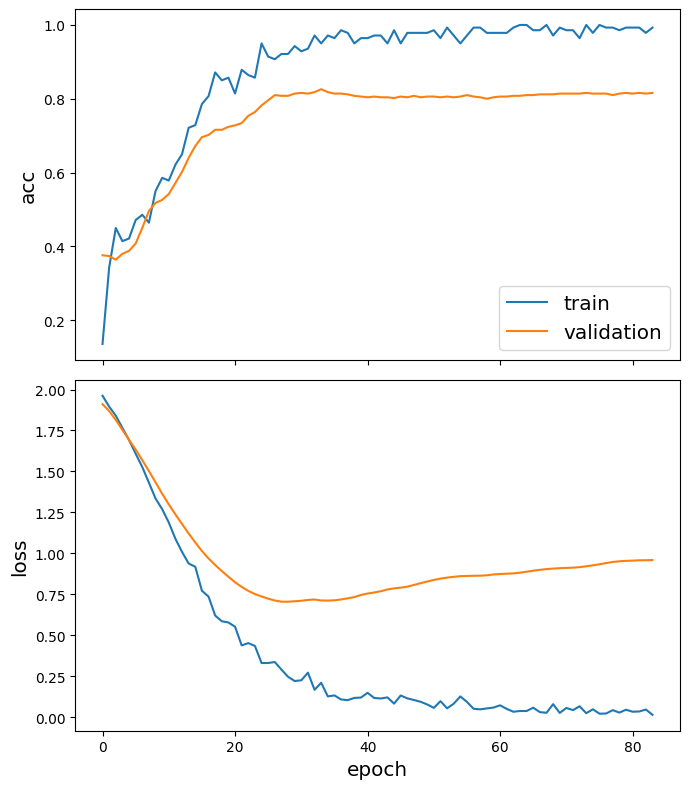

In [20]:
sg.utils.plot_history(history)



In [21]:
test_gen = generator.flow(test_subjects.index, test_targets)



In [22]:
test_metrics = model.evaluate(test_gen)
print("\nTest Set Metrics:")
for name, val in zip(model.metrics_names, test_metrics):
    print("\t{}: {:0.4f}".format(name, val))


1/1 [==============================] - 0s 70ms/step - loss: 0.7002 - acc: 0.7926

Test Set Metrics:
	loss: 0.7002
	acc: 0.7926


In [23]:
all_nodes = node_subjects.index
all_gen = generator.flow(all_nodes)
all_predictions = model.predict(all_gen)

1/1 [==============================] - 0s 217ms/step


In [24]:
node_predictions = target_encoding.inverse_transform(all_predictions.squeeze())

In [25]:
df = pd.DataFrame({"Predicted": node_predictions, "True": node_subjects})
df.head(20)

,Predicted,True
31336,Probabilistic_Methods,Neural_Networks
1061127,Rule_Learning,Rule_Learning
1106406,Reinforcement_Learning,Reinforcement_Learning
13195,Reinforcement_Learning,Reinforcement_Learning
37879,Probabilistic_Methods,Probabilistic_Methods
1126012,Probabilistic_Methods,Probabilistic_Methods
1107140,Case_Based,Theory
1102850,Theory,Neural_Networks
31349,Probabilistic_Methods,Neural_Networks
1106418,Theory,Theory


In [26]:
embedding_model = Model(inputs=x_inp, outputs=x_out)

In [27]:
emb = embedding_model.predict(all_gen)
emb.shape

1/1 [==============================] - 0s 129ms/step


(1, 2708, 16)

In [28]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

transform = TSNE  # or PCA



In [29]:
X = emb.squeeze(0)
X.shape



(2708, 16)

In [30]:
trans = transform(n_components=2)
X_reduced = trans.fit_transform(X)
X_reduced.shape

(2708, 2)

[None,
 Text(0.5, 0, '$X_1$'),
 Text(0, 0.5, '$X_2$'),
 Text(0.5, 1.0, 'TSNE visualization of GCN embeddings for cora dataset')]

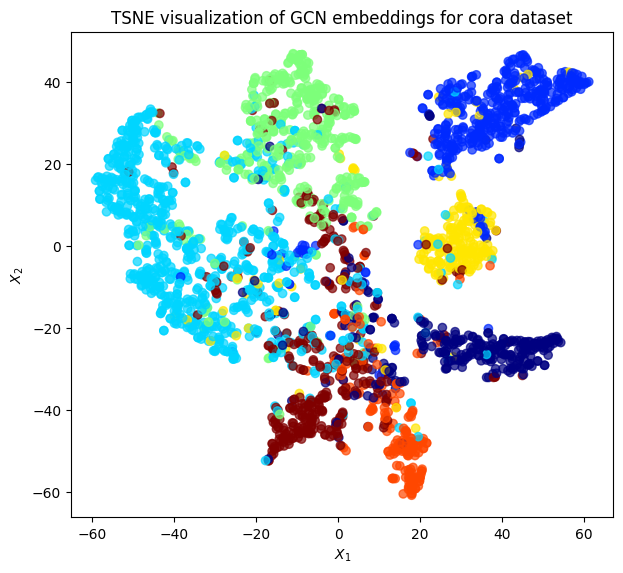

In [31]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=node_subjects.astype("category").cat.codes,
    cmap="jet",
    alpha=0.7,
)
ax.set(
    aspect="equal",
    xlabel="$X_1$",
    ylabel="$X_2$",
    title=f"{transform.__name__} visualization of GCN embeddings for cora dataset",
)

